In [ ]:
import os
import shutil

base_dir = "/content/tiny-imagenet-200"
val_dir = os.path.join(base_dir, "val")
images_dir = os.path.join(val_dir, "images")
ann_file = os.path.join(val_dir, "val_annotations.txt")

# Read annotations
with open(ann_file) as f:
    annotations = [line.strip().split('\t') for line in f]

# Create class folders and move images
for img, cls, *_ in annotations:
    cls_dir = os.path.join(val_dir, cls)
    os.makedirs(cls_dir, exist_ok=True)
    shutil.move(
        os.path.join(images_dir, img),
        os.path.join(cls_dir, img)
    )

# Optional: remove old images dir
os.rmdir(images_dir)


In [ ]:
import tensorflow as tf
import tensorflow.keras.layers as tfla
import tensorflow.keras.models as tfm
import tensorflow.keras.optimizers as tfo
import tensorflow.keras.losses as tflo
import matplotlib.pyplot as plt

In [ ]:
# load training set
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/tiny-imagenet-200/train",
    image_size=(224, 224),
    batch_size=64,
    label_mode="int"
)

# load test set, we use validation set as test set, as test set is not labelled
test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/tiny-imagenet-200/val",
    image_size=(224, 224),
    batch_size=64,
    label_mode="int"
)

Found 100000 files belonging to 200 classes.
Found 10000 files belonging to 200 classes.


In [ ]:
def compute_mean(dataset):
    total = tf.zeros([3], dtype=tf.float32)
    count = tf.constant(0, dtype=tf.int64)

    for images, _ in dataset:
        images = tf.cast(images, tf.float32)
        pixels = tf.reshape(images, [-1, 3])
        total += tf.reduce_sum(pixels, axis=0)
        count += tf.cast(tf.shape(pixels)[0], tf.int64)

    return(total / tf.cast(count, tf.float32))

def subtract_mean(images, labels):
    images = tf.cast(images, tf.float32)
    images = images - mean
    return(images, labels)

# find mean and subtract each pixel from mean
mean = compute_mean(train_ds)
train_ds = train_ds.map(subtract_mean)
test_ds = test_ds.map(subtract_mean)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

def collect_pixels(dataset, max_batch=20):
    all_pixels = []
    i = 0
    for images, _ in dataset:
        images = tf.cast(images, tf.float32)
        pixels = tf.reshape(images, [-1, 3])
        all_pixels.append(pixels)

        i+=1
        if(i >= max_batch):
            break


    return(tf.concat(all_pixels, axis=0))

def compute_pca(pixels):
    mean = tf.reduce_mean(pixels, axis=0)

    centered = pixels - mean

    cov = tf.matmul(centered, centered, transpose_a=True)
    cov /= tf.cast(tf.shape(centered)[0], tf.float32)

    eigvals, eigvecs = tf.linalg.eigh(cov)

    idx = tf.argsort(eigvals, direction="DESCENDING")
    eigvals = tf.gather(eigvals, idx)
    eigvecs = tf.gather(eigvecs, idx, axis=1)

    return(eigvals, eigvecs)

all_pixels = collect_pixels(train_ds, 100)
# we use first 100 batches, as using all the data will run out of
# ram
eigvals, eigvecs = compute_pca(all_pixels)
eigvals = eigvals / tf.reduce_max(eigvals)

print(eigvals)
print("\n")
print(eigvecs)

def apply_pca_to_image(image, eigvals, eigvecs):
    alpha = tf.random.normal([3], mean=0.0, stddev=0.1)
    delta = tf.reduce_sum(eigvecs * eigvals * alpha, axis=1)

    return(tf.clip_by_value(image + delta, -128, 128))

def apply_pca_to_batch(images, labels):
    images = tf.cast(images, tf.float32)

    images = tf.map_fn(lambda img : apply_pca_to_image(img, eigvals, eigvecs), images)

    return(images, labels)

# apply pca to images
train_ds = train_ds.map(apply_pca_to_batch)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

kernel_init = tf.keras.initializers.RandomNormal(
    mean=0.0,
    stddev=0.01
)

bias_zeros = tf.keras.initializers.Zeros()
bias_ones = tf.keras.initializers.Ones()

tf.Tensor([1.         0.09703886 0.01984956], shape=(3,), dtype=float32)


tf.Tensor(
[[ 0.56486875  0.72727114 -0.38987187]
 [ 0.58254963 -0.01683843  0.81262064]
 [ 0.5844309  -0.68614376 -0.43318295]], shape=(3, 3), dtype=float32)


In [ ]:
inputs = tfla.Input(shape=(224, 224, 3))

# conv block 1
x = tfla.Conv2D(96, kernel_size=11, strides=4, activation='relu',
                kernel_initializer=kernel_init, bias_initializer=bias_zeros, padding='valid')(inputs)
x = tfla.Lambda(lambda x : tf.nn.local_response_normalization(x, depth_radius=2, bias=2,
                                                          alpha=1e-4, beta=0.75))(x)
x = tfla.MaxPooling2D(pool_size=3, strides=2)(x)

# conv block 2
x = tfla.ZeroPadding2D(padding=2)(x)
x = tfla.Conv2D(256, kernel_size=5, strides=1, activation='relu',
                kernel_initializer=kernel_init, bias_initializer=bias_ones, padding='valid')(x)
x = tfla.Lambda(lambda x : tf.nn.local_response_normalization(x, depth_radius=2, bias=2,
                                                          alpha=1e-4, beta=0.75))(x)
x = tfla.MaxPooling2D(pool_size=3, strides=2)(x)

# conv block 3
x = tfla.ZeroPadding2D(padding=1)(x)
x = tfla.Conv2D(384, kernel_size=3, strides=1, activation='relu',
                padding='valid')(x)

# conv block 4
x = tfla.ZeroPadding2D(padding=1)(x)
x = tfla.Conv2D(384, kernel_size=3, strides=1, activation='relu',
                padding='valid')(x)

# conv block 5
x = tfla.ZeroPadding2D(padding=1)(x)
x = tfla.Conv2D(256, kernel_size=3, strides=1, activation='relu',
                padding='valid')(x)
x = tfla.MaxPooling2D(pool_size=3, strides=2)(x)

x = tfla.Flatten()(x)

# FC 6
x = tfla.Dense(4096, activation='relu', kernel_initializer=kernel_init, bias_initializer=bias_zeros)(x)
x = tfla.Dropout(0.3)(x)

# FC 7
x = tfla.Dense(4096, activation='relu', kernel_initializer=kernel_init, bias_initializer=bias_zeros)(x)
x = tfla.Dropout(0.3)(x)

# FC 8
outputs = tfla.Dense(200, activation='softmax')(x)

model = tfm.Model(inputs, outputs)

optimizer = tfo.SGD(
    learning_rate=0.001,
    momentum=0.9,
    clipnorm=1.0
)

model.compile(
    optimizer = optimizer,
    loss = tflo.SparseCategoricalCrossentropy(from_logits = False),
    metrics = ["accuracy"]
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "alexnet.weights.h5",
    monitor="loss",
    save_weights_only=True,
    save_best_only=True,
)

def lr_schedule(epoch, lr):
    if(epoch < 20):
        return(0.001)
    else:
        if(epoch < 40):
            return(0.0001)
        else:
            if(epoch < 60):
                return(0.00001)
            else:
                if(epoch < 80):
                    return(0.000001)
                else:
                    return(0.0000001)

lr_callback = tf.keras.callbacks.LearningRateScheduler(lr_schedule)

history = model.fit(
    train_ds,
    epochs=100,
    callbacks=[checkpoint, lr_callback]
)

print("\nevaluation:\n")
model.evaluate(test_ds)

Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 98s 54ms/step - accuracy: 0.0156 - loss: 5.1886 - learning_rate: 0.0010
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.0553 - loss: 4.7403 - learning_rate: 0.0010
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.0923 - loss: 4.3987 - learning_rate: 0.0010
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.1274 - loss: 4.1339 - learning_rate: 0.0010
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.1550 - loss: 3.9397 - learning_rate: 0.0010
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.1779 - loss: 3.7829 - learning_rate: 0.0010
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.1993 - loss: 3.6440 - learning_rate: 0.0010
Epoch 8/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.2157 - loss: 3.5372 - learning_rate: 0.0010
Epoch 9/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.2335 - lo

[2.8492534160614014, 0.3418999910354614]

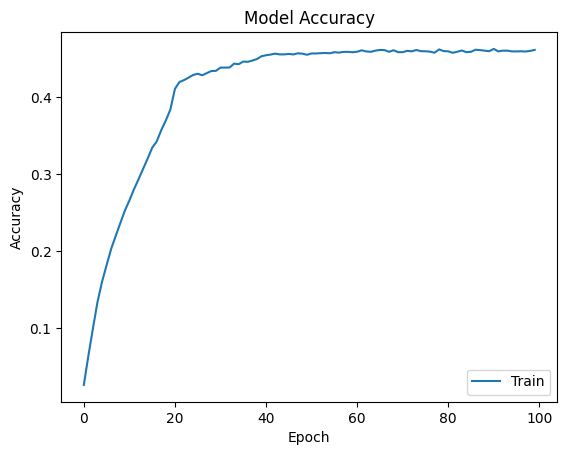

In [ ]:
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='lower right')
plt.show()